In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

### Dataset:
Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

Donated by:
P. Savicky
Institute of Computer Science, AS of CR
Czech Republic
savicky '@' cs.cas.cz

In [2]:
cols = [
	"fLength",
	"fWidth",
	"fSize",
	"fConc",
	"fConc1",
	"fAsym",
	"fM3Long",
	"fM3Trans",
	"fAlpha",
	"fDist",
	"class",
]
url = "https://raw.githubusercontent.com/jhlopesalves/data-science-notebooks/refs/heads/main/Python/projects/fcc_magic_gamma/data/magic04.data"
df = pd.read_csv(url, names=cols, usecols=lambda col: not col.startswith("Unnamed"))
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
# Binary encode: gamma ('g') → 1, hadron ('h') → 0, as int8
df["class"] = (df["class"].str.lower() == "g").astype("int8")

# Basic sanity check
class_counts = df["class"].value_counts().sort_index()
print({0: int(class_counts.get(0, 0)), 1: int(class_counts.get(1, 1))})


{0: 6688, 1: 12332}


In [4]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


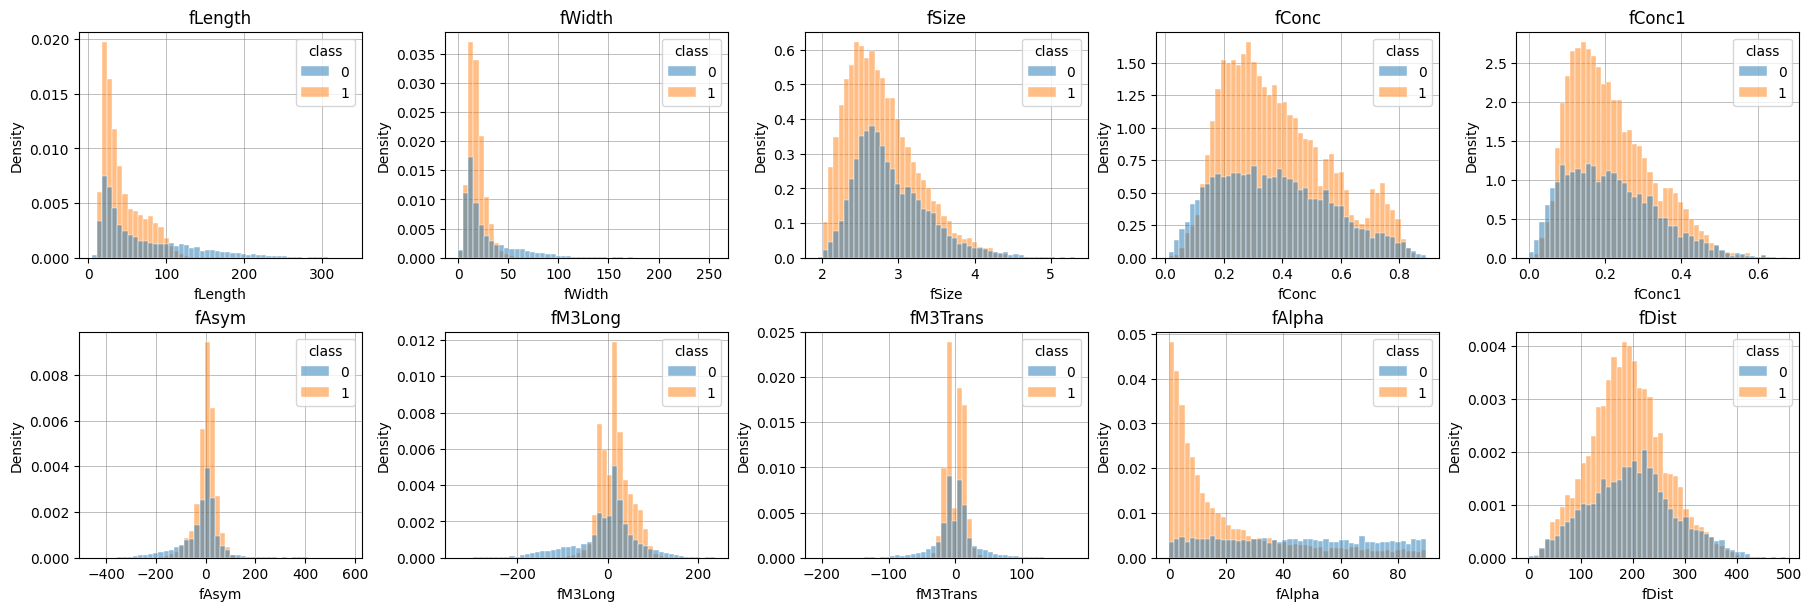

In [5]:
feature_names = cols[:-1]
num_features = len(feature_names)

# Grid size: 2 rows × 5 cols for 10 features
fig, axes = plt.subplots(2, 5, figsize=(18, 6), constrained_layout=True)
axes = axes.ravel()

for axis, feature in zip(axes, feature_names):
    sns.histplot(
        data=df,
        x=feature,
        hue="class",
        hue_order=[0, 1],
        stat="density",
        bins=50,
        alpha=0.5,
        edgecolor="white",
        linewidth=0.3,
        ax=axis,
    )
    axis.set_title(feature)
    axis.set_xlabel(feature)
    axis.set_ylabel("Density")
    axis.grid(True, alpha=0.6, linewidth=0.6, color="grey")
    axis.set_axisbelow(True)

# Single, consistent legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["hadron (0)", "gamma (1)"], loc="upper right", frameon=False)
plt.show()


# Train, validation, test datasets

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

def scale_dataset(dataframe, oversample=False):
    X = dataframe.drop("class", axis=1).copy()
    y = dataframe["class"].copy()

    # First: pull out 20% test
    X_train_valid, X_test, y_train_valid, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42
    )

    # Second: from the remaining 80%, take 25% for validation -> 0.25 * 0.80 = 0.20 overall
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_valid, y_train_valid, test_size=0.25, stratify=y_train_valid, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)
    X_test = scaler.transform(X_test)

    if oversample:
        ros = RandomOverSampler()
        X_train, y_train = ros.fit_resample(X_train, y_train)

    train = np.hstack((X_train, np.reshape(y_train, (-1, 1))))
    valid = np.hstack((X_valid, np.reshape(y_valid, (-1, 1))))
    test = np.hstack((X_test, np.reshape(y_test, (-1, 1))))

    return (train, X_train, y_train), (valid, X_valid, y_valid), (test, X_test, y_test)

In [11]:
(train, X_train, y_train), (valid, X_valid, y_valid), (test, X_test, y_test) = scale_dataset(df, oversample=True)

## KNN

In [12]:
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

In [13]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [14]:
y_pred = knn_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      1338
           1       0.85      0.85      0.85      2466

    accuracy                           0.80      3804
   macro avg       0.78      0.78      0.78      3804
weighted avg       0.80      0.80      0.80      3804



## Naive Bayes

In [15]:
from sklearn.naive_bayes import GaussianNB

In [16]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [17]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.41      0.51      1338
           1       0.74      0.89      0.81      2466

    accuracy                           0.72      3804
   macro avg       0.71      0.65      0.66      3804
weighted avg       0.72      0.72      0.70      3804



## Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [20]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.71      0.69      1338
           1       0.84      0.82      0.83      2466

    accuracy                           0.78      3804
   macro avg       0.76      0.76      0.76      3804
weighted avg       0.78      0.78      0.78      3804



## Support-Vector Classification (SVC)

In [21]:
from sklearn.svm import SVC

In [22]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [23]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1338
           1       0.89      0.90      0.90      2466

    accuracy                           0.86      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.86      0.86      0.86      3804



### Neural Networks

In [24]:
import tensorflow as tf

In [25]:
print("TensorFlow:", tf.__version__)
print("TF built with CUDA:", tf.test.is_built_with_cuda())

TensorFlow: 2.19.0
TF built with CUDA: True


In [26]:
# List and configure GPU(s)
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detected and memory growth set: {[g.name for g in gpus]}")
    except Exception as e:
        print("Could not set memory growth:", e)
else:
    print("No GPU detected. In Colab: Runtime → Change runtime type → Hardware accelerator → GPU.")

# Optional: enable XLA JIT for a small speed boost on many models
tf.config.optimizer.set_jit(True)

GPUs detected and memory growth set: ['/physical_device:GPU:0']


In [29]:
def plot_history(history: tf.keras.callbacks.History) -> None:
    """Plot loss and accuracy with a marker at the best val_loss epoch."""
    hist = history.history
    best_epoch = int(np.argmin(hist["val_loss"]))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    ax1.plot(hist["loss"], label="train")
    ax1.plot(hist["val_loss"], label="valid")
    ax1.scatter([best_epoch], [hist["val_loss"][best_epoch]], marker="x", s=80)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Binary crossentropy")
    ax1.grid(True)
    ax1.legend(title="Loss")

    if "accuracy" in hist and "val_accuracy" in hist:
        ax2.plot(hist["accuracy"], label="train")
        ax2.plot(hist["val_accuracy"], label="valid")
        ax2.scatter([best_epoch], [hist["val_accuracy"][best_epoch]], marker="x", s=80)
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Accuracy")
        ax2.grid(True)
        ax2.legend(title="Accuracy")

    plt.show()


In [33]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler

def fit_preprocessor(X_train_array: np.ndarray) -> StandardScaler:
    """Fit a StandardScaler on the training features only."""
    scaler = StandardScaler()
    scaler.fit(X_train_array.astype("float32"))
    return scaler

def transform_features(X_array: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Apply a fitted scaler to any split. Always return float32 for TF."""
    return scaler.transform(X_array.astype("float32")).astype("float32")

def oversample_train(
    X_train_array: np.ndarray, y_train_array: np.ndarray, seed: int = 42
) -> tuple[np.ndarray, np.ndarray]:
    """Randomly oversample the minority class on the training set only."""
    ros = RandomOverSampler(random_state=seed)
    X_res, y_res = ros.fit_resample(X_train_array, y_train_array)
    return X_res.astype("float32"), y_res.astype("int8")

In [34]:
def make_dataset(
    X_array: np.ndarray,
    y_array: np.ndarray,
    batch_size: int,
    shuffle: bool,
    seed: int = 42,
) -> tf.data.Dataset:
    """A simple tf.data pipeline with optional shuffle and prefetch."""
    ds = tf.data.Dataset.from_tensor_slices((X_array, y_array))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_array), seed=seed, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Fit scaler on TRAIN only
scaler = fit_preprocessor(X_train)

# Transform all splits with the same scaler
X_train_s = transform_features(X_train, scaler)
X_valid_s = transform_features(X_valid, scaler)
X_test_s  = transform_features(X_test,  scaler)

# Oversample TRAIN only
X_train_bal, y_train_bal = oversample_train(X_train_s, y_train.values)

# TensorFlow datasets
BATCH_SIZE = 64
train_ds = make_dataset(X_train_bal, y_train_bal, batch_size=BATCH_SIZE, shuffle=True)
valid_ds = make_dataset(X_valid_s,  y_valid.values,     batch_size=BATCH_SIZE, shuffle=False)
test_ds  = make_dataset(X_test_s,   y_test.values,      batch_size=BATCH_SIZE, shuffle=False)

In [35]:
from typing import Tuple

def build_model(
    input_dim: int,
    num_nodes: int,
    dropout_prob: float,
    learning_rate: float,
) -> tf.keras.Model:
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(input_dim,)),
            tf.keras.layers.Dense(num_nodes, activation="relu"),
            tf.keras.layers.Dropout(dropout_prob),
            tf.keras.layers.Dense(num_nodes, activation="relu"),
            tf.keras.layers.Dropout(dropout_prob),
            tf.keras.layers.Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
        ],
    )
    return model

def train_model(
    train_ds: tf.data.Dataset,
    valid_ds: tf.data.Dataset,
    input_dim: int,
    num_nodes: int,
    dropout_prob: float,
    learning_rate: float,
    epochs: int,
) -> Tuple[tf.keras.Model, tf.keras.callbacks.History]:
    model = build_model(
        input_dim=input_dim,
        num_nodes=num_nodes,
        dropout_prob=dropout_prob,
        learning_rate=learning_rate,
    )

    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=0
    )
    reduce = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0
    )

    history = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=epochs,
        callbacks=[early, reduce],
        verbose=0,
    )
    return model, history


nodes=16 drop=0.0 lr=0.01 batch=32
nodes=16 drop=0.0 lr=0.01 batch=64
nodes=16 drop=0.0 lr=0.01 batch=128
nodes=16 drop=0.0 lr=0.005 batch=32
nodes=16 drop=0.0 lr=0.005 batch=64
nodes=16 drop=0.0 lr=0.005 batch=128
nodes=16 drop=0.0 lr=0.001 batch=32
nodes=16 drop=0.0 lr=0.001 batch=64
nodes=16 drop=0.0 lr=0.001 batch=128
nodes=16 drop=0.2 lr=0.01 batch=32
nodes=16 drop=0.2 lr=0.01 batch=64
nodes=16 drop=0.2 lr=0.01 batch=128
nodes=16 drop=0.2 lr=0.005 batch=32
nodes=16 drop=0.2 lr=0.005 batch=64
nodes=16 drop=0.2 lr=0.005 batch=128
nodes=16 drop=0.2 lr=0.001 batch=32
nodes=16 drop=0.2 lr=0.001 batch=64
nodes=16 drop=0.2 lr=0.001 batch=128
nodes=32 drop=0.0 lr=0.01 batch=32
nodes=32 drop=0.0 lr=0.01 batch=64
nodes=32 drop=0.0 lr=0.01 batch=128
nodes=32 drop=0.0 lr=0.005 batch=32
nodes=32 drop=0.0 lr=0.005 batch=64
nodes=32 drop=0.0 lr=0.005 batch=128
nodes=32 drop=0.0 lr=0.001 batch=32
nodes=32 drop=0.0 lr=0.001 batch=64
nodes=32 drop=0.0 lr=0.001 batch=128
nodes=32 drop=0.2 lr=0.01 ba

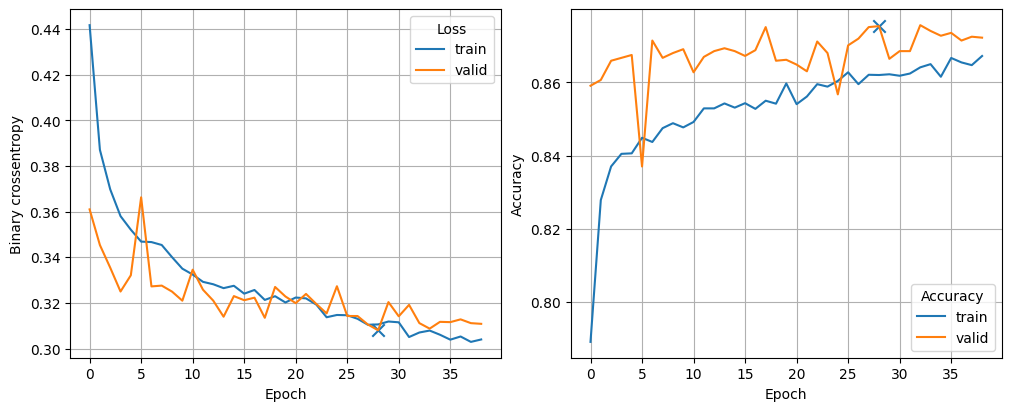

In [37]:
from itertools import product

EPOCHS = 100
INPUT_DIM = X_train_s.shape[1]

search_space = {
    "num_nodes":   [16, 32, 64],
    "dropout_prob":[0.0, 0.2],
    "learning_rate":[1e-2, 5e-3, 1e-3],
    "batch_size":  [32, 64, 128],
}

best = {"val_loss": np.inf, "cfg": None, "model": None, "history": None}

# Rebuild datasets when batch size changes
for num_nodes, dropout_prob, learning_rate, batch_size in product(
    search_space["num_nodes"],
    search_space["dropout_prob"],
    search_space["learning_rate"],
    search_space["batch_size"],
):
    print(
        f"nodes={num_nodes} drop={dropout_prob} lr={learning_rate} batch={batch_size}"
    )

    train_ds = make_dataset(X_train_bal, y_train_bal, batch_size=batch_size, shuffle=True)
    valid_ds = make_dataset(X_valid_s,  y_valid.values,     batch_size=batch_size, shuffle=False)

    model, history = train_model(
        train_ds=train_ds,
        valid_ds=valid_ds,
        input_dim=INPUT_DIM,
        num_nodes=num_nodes,
        dropout_prob=dropout_prob,
        learning_rate=learning_rate,
        epochs=EPOCHS,
    )

    # Evaluate on validation set
    eval_dict = model.evaluate(valid_ds, return_dict=True, verbose=0)
    val_loss = float(eval_dict["loss"])

    if val_loss < best["val_loss"]:
        best = {
            "val_loss": val_loss,
            "cfg": {
                "num_nodes": num_nodes,
                "dropout_prob": dropout_prob,
                "learning_rate": learning_rate,
                "batch_size": batch_size,
            },
            "model": model,
            "history": history,
        }

print("Best configuration:", best["cfg"], "val_loss:", round(best["val_loss"], 5))
plot_history(best["history"])

In [39]:
y_pred = best['model'].predict(X_test_s)
y_pred = (y_pred > 0.5).astype(int).reshape(-1,)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [40]:
print(classification_report(y_test.values, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1338
           1       0.90      0.90      0.90      2466

    accuracy                           0.87      3804
   macro avg       0.86      0.86      0.86      3804
weighted avg       0.87      0.87      0.87      3804

